## 05 モデル比較

ここでは、同じ特徴量・同じtrain/test分割を使って、複数モデルを比較する

比較するモデル：

- LogisticRegression
- RandomForest
- ExtraTrees
- GradientBoosting
- LightGBM


In [11]:
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
)
from lightgbm import LGBMClassifier

NUMERIC_COLUMNS = [
    "temperature",
    "humidity",
    "pressure",
    "precipitation",
    "wind_speed",
    "cloud_amount",
]

CATEGORICAL_COLUMNS = [
    "wind_direction",
]

In [12]:
def time_train_test_split(feature_df: pd.DataFrame, test_ratio: float = 0.2):
    split_idx = int(len(feature_df) * (1 - test_ratio))
    train_df = feature_df.iloc[:split_idx].copy()
    test_df = feature_df.iloc[split_idx:].copy()
    return train_df, test_df


def get_xy(feature_df: pd.DataFrame):
    drop_cols = [
        "datetime",
        "target_weather_class",
    ]
    X = feature_df.drop(columns=[c for c in drop_cols if c in feature_df.columns])
    y = feature_df["target_weather_class"].astype(int)

    return X, y

def evaluate_model(model, X_train, y_train, X_test, y_test, label="model"):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    metrics = {
        "model": label,
        "accuracy": accuracy_score(y_test, pred),
        "macro_f1": f1_score(y_test, pred, average="macro"),
        "weighted_f1": f1_score(y_test, pred, average="weighted"),
    }

    print(f"## {label}")
    print(metrics)
    print()
    print(classification_report(y_test, pred, zero_division=0))

    return metrics, pred


## 特徴量データを読み込む

`02_feature_engineering.ipynb`で保存した特徴量CSVを読み込む

In [13]:
feature_path = Path("./data/features_weather_24h.csv")

if feature_path.exists():
    feature_df = pd.read_csv(feature_path, parse_dates=["datetime"])
else:
    print("先に02_feature_engineering.ipynbを実行してCSVを作成してください")

feature_df = feature_df.dropna().reset_index(drop=True)

train_df, test_df = time_train_test_split(feature_df, test_ratio=0.2)
X_train, y_train = get_xy(train_df)
X_test, y_test = get_xy(test_df)

print(X_train.shape, X_test.shape)

(28002, 189) (7001, 189)


## モデル一覧を作る

LogisticRegressionは線形モデルなので、標準化を入れる

（木系モデルは標準化なしでも扱いやすい）

In [14]:
models = {
    "logistic_regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
        )),
    ]),
    "random_forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced_subsample",
    ),
    "extra_trees": ExtraTreesClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
    ),
    "gradient_boosting": GradientBoostingClassifier(
        random_state=42,
    ),
    "lightgbm": LGBMClassifier(
        random_state=42,
        class_weight="balanced",
        n_estimators=300,
        verbosity=-1,
    ),
}

## モデル比較を実行する

評価指標は以下を使う

- Accuracy: 全体の正解率
- Macro F1: クラスごとのF1を単純平均。少数クラスに厳しい
- Weighted F1: クラスの件数で重み付けしたF1

天気コードは偏りがあるため、Accuracyだけでは不十分となる


In [15]:
comparison_results = []
predictions = {}

for name, model in models.items():
    metrics, pred = evaluate_model(model, X_train, y_train, X_test, y_test, label=name)
    comparison_results.append(metrics)
    predictions[name] = pred

comparison_df = pd.DataFrame(comparison_results)
display(comparison_df.sort_values("weighted_f1", ascending=False))

## logistic_regression
{'model': 'logistic_regression', 'accuracy': 0.3863733752321097, 'macro_f1': 0.18659750567407896, 'weighted_f1': 0.428648271851126}

              precision    recall  f1-score   support

           1       0.75      0.44      0.55      3866
           2       0.30      0.27      0.28      2100
           3       0.20      0.44      0.27       999
           4       0.00      0.00      0.00         0
           5       0.01      0.12      0.01        33
           6       0.00      0.00      0.00         3

    accuracy                           0.39      7001
   macro avg       0.21      0.21      0.19      7001
weighted avg       0.53      0.39      0.43      7001

## random_forest
{'model': 'random_forest', 'accuracy': 0.5407798885873447, 'macro_f1': 0.20810650594497412, 'weighted_f1': 0.4816375756882543}

              precision    recall  f1-score   support

           1       0.59      0.83      0.69      3866
           2       0.38      0.26      0.31    

,model,accuracy,macro_f1,weighted_f1
3,gradient_boosting,0.551778,0.192935,0.511027
4,lightgbm,0.511356,0.238187,0.500139
2,extra_trees,0.548922,0.212683,0.488478
1,random_forest,0.540780,0.208107,0.481638
0,logistic_regression,0.386373,0.186598,0.428648


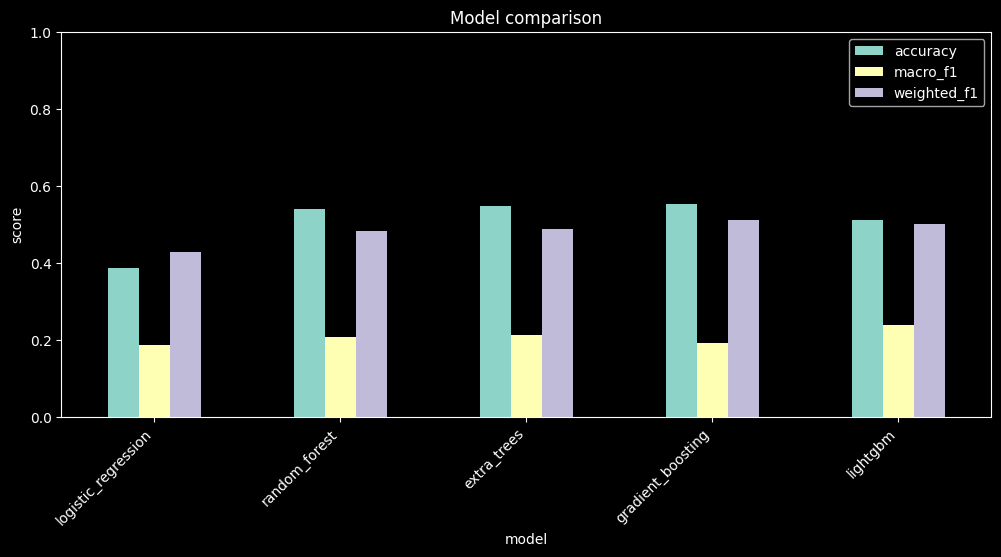

In [16]:
ax = comparison_df.set_index("model")[["accuracy", "macro_f1", "weighted_f1"]].plot(
    kind="bar",
    figsize=(12, 5),
)
plt.title("Model comparison")
plt.ylabel("score")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.show()

## TimeSeriesSplitによる簡易クロスバリデーション

単一のtrain/testだけだと、たまたまその期間に強かった可能性がある

そこで、時系列を保った分割で複数回評価する

注意:
通常のKFoldはランダム性が入りやすいため、時系列データではTimeSeriesSplitを使う


In [17]:
from sklearn.base import clone

tscv = TimeSeriesSplit(n_splits=5)

cv_results = []

for model_name, model in models.items():
    fold_scores = []

    for fold, (train_idx, valid_idx) in enumerate(tscv.split(X_train), start=1):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[valid_idx]

        m = clone(model)
        m.fit(X_tr, y_tr)
        pred = m.predict(X_val)

        fold_scores.append({
            "model": model_name,
            "fold": fold,
            "accuracy": accuracy_score(y_val, pred),
            "macro_f1": f1_score(y_val, pred, average="macro"),
            "weighted_f1": f1_score(y_val, pred, average="weighted"),
        })

    cv_results.extend(fold_scores)

cv_df = pd.DataFrame(cv_results)
display(cv_df.groupby("model")[["accuracy", "macro_f1", "weighted_f1"]].mean().sort_values("weighted_f1", ascending=False))

,accuracy,macro_f1,weighted_f1
model,,,
lightgbm,0.539361,0.237636,0.522162
random_forest,0.576559,0.231545,0.521118
extra_trees,0.575059,0.228557,0.516316
gradient_boosting,0.537647,0.218003,0.502270
logistic_regression,0.449239,0.243908,0.471223


## 特徴量重要度を見る

木系モデルでは、どの特徴量が重要だったかを確認できる

例:

- `weather_code_lag_24h` が効いている
- `pressure_diff_6h` が効いている
- `humidity_mean_24h` が効いている

こういった結果から、気象現象としての考察につなげられる


dayofyear                1174
pressure_diff_24h         899
temperature_std_24h       814
humidity_std_24h          756
humidity_min_24h          740
wind_speed_max_24h        716
temperature_max_24h       704
pressure_std_24h          697
wind_speed_std_24h        673
temperature_diff_24h      625
pressure_max_24h          625
wind_speed_mean_24h       622
pressure_lag_24h          619
temperature_min_24h       599
cloud_amount_std_24h      577
wind_speed_min_24h        553
pressure_min_24h          547
humidity_mean_24h         539
cloud_amount_mean_24h     486
temperature_min_12h       467
humidity_max_24h          448
pressure_std_12h          447
temperature_lag_12h       445
wind_speed_max_12h        416
temperature_mean_24h      413
pressure_min_12h          396
wind_speed_std_12h        393
temperature_lag_24h       393
wind_speed_mean_12h       390
temperature_std_12h       376
dtype: int32

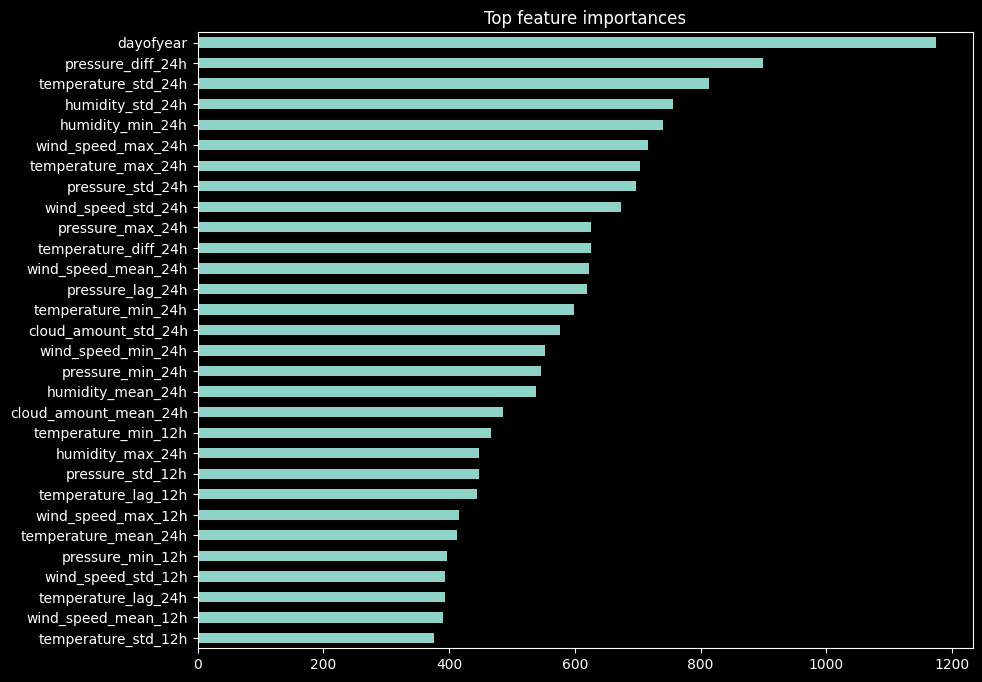

In [18]:
best_tree_model_name = "lightgbm"
best_tree_model = models[best_tree_model_name]

# まだfit済みのインスタンスなので、そのまま使える想定
if hasattr(best_tree_model, "feature_importances_"):
    importances = pd.Series(best_tree_model.feature_importances_, index=X_train.columns)
    top_importances = importances.sort_values(ascending=False).head(30)

    display(top_importances)

    ax = top_importances.sort_values().plot(kind="barh", figsize=(10, 8))
    plt.title("Top feature importances")
    plt.show()
else:
    print("このモデルでは feature_importances_ が使えません")